In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch: {torch.__version__}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

PyTorch: 2.10.0+cpu
Device: cpu


In [ ]:
import requests
import io
import zipfile

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00372/HTRU2.zip"

# Download the zip file
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# Extract the CSV file and read it into a DataFrame
with zip_file.open('HTRU_2.csv') as file:
    df = pd.read_csv(file, header=None)

df.columns = [
    'mean_ip', 'std_ip', 'kurtosis_ip', 'Skewness_ip',
    'mean_dmsnr', 'std_dmsnr', 'kurtosis_dms', 'Skewness_dmsnr',
    'is_pulsar'
]

print(f"Dataset: {df.shape[0]:,} samples, {df.shape[1]} columns")
df.head()

Dataset: 17,898 samples, 9 columns


,mean_ip,std_ip,kurtosis_ip,Skewness_ip,mean_dmsnr,std_dmsnr,kurtosis_dms,Skewness_dmsnr,is_pulsar
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [ ]:
print("Class Distribution:")
print(df['is_pulsar'].value_counts())
print(f"\nPulsar rate: {df['is_pulsar'].mean():.1%} (imbalanced!)")

Class Distribution:
is_pulsar
0    16259
1     1639
Name: count, dtype: int64

Pulsar rate: 9.2% (imbalanced!)


In [ ]:
x = df.drop('is_pulsar', axis=1)
y = df['is_pulsar'].values

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

print(f"Train: {x_train.shape[0]:,} | Val: {x_val.shape[0]:,} | Test: {x_test.shape[0]:,}")

Train: 14,318 | Val: 1,790 | Test: 1,790


In [ ]:
x_train_t = torch.FloatTensor(x_train).to(device)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
x_val_t = torch.FloatTensor(x_val).to(device)
y_val_t = torch.FloatTensor(y_val).reshape(-1, 1).to(device)
x_test_t = torch.FloatTensor(x_test).to(device)
y_test_t = torch.FloatTensor(y_test).reshape(-1, 1).to(device)

train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val_t, y_val_t), batch_size=64)

In [ ]:
class BaselineNet(nn.Module):
  def __init__(self, input_size):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.net(x)

print(BaselineNet(8))

BaselineNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=100, verbose=True):
  train_losses, val_losses = [], []
  train_accs, val_accs = [], []

  for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    total=0

    for x_batch, y_batch in train_loader:
      optimizer.zero_grad()
      outputs = model(x_batch)
      loss = criterion(outputs, y_batch)
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()
      predicted = (outputs > 0.5).float()
      correct += (predicted == y_batch).sum().item()
      total += y_batch.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accs.append(correct / total)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
      for x_batch, y_batch in val_loader:
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        val_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)

    if verbose and epoch % 20 == 0:
      print(f"Epoch {epoch:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2%}")
  return train_losses, val_losses, train_accs, val_accs

In [ ]:
model_baseline = BaselineNet(8).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_baseline.parameters(), lr=0.01)
baseline_results = train_model(model_baseline, train_loader, val_loader, optimizer, criterion, epochs=100)

Epoch   0 | Train Loss: 0.1032 | Val Loss: 0.0699 | Val Acc: 98.04%
Epoch  20 | Train Loss: 0.0657 | Val Loss: 0.0715 | Val Acc: 98.04%
Epoch  40 | Train Loss: 0.0629 | Val Loss: 0.0702 | Val Acc: 98.04%
Epoch  60 | Train Loss: 0.0621 | Val Loss: 0.0694 | Val Acc: 97.82%
Epoch  80 | Train Loss: 0.0607 | Val Loss: 0.0714 | Val Acc: 97.93%


In [ ]:
# Compare SGD, Adam, RMSprop
optimizers_config = {
    'SGD': lambda params: optim.SGD(params, lr=0.01),
    'SGD + Momentum': lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    'RMSprop': lambda params: optim.RMSprop(params, lr=0.001),
    'Adam': lambda params: optim.Adam(params, lr=0.001),
    'AdamW': lambda params: optim.AdamW(params, lr=0.001, weight_decay=0.01)
}

optimizer_results = {}

for name, opt_fn in optimizers_config.items():
    print(f"\nTraining with {name}...")
    model = BaselineNet(8).to(device)
    optimizer = opt_fn(model.parameters())
    results = train_model(model, train_loader, val_loader, optimizer, criterion, epochs=100, verbose=False)
    optimizer_results[name] = results
    print(f"  Final Val Acc: {results[3][-1]:.2%}")


Training with SGD...
  Final Val Acc: 98.04%

Training with SGD + Momentum...
  Final Val Acc: 97.99%

Training with RMSprop...
  Final Val Acc: 97.82%

Training with Adam...
  Final Val Acc: 97.99%

Training with AdamW...
  Final Val Acc: 98.04%


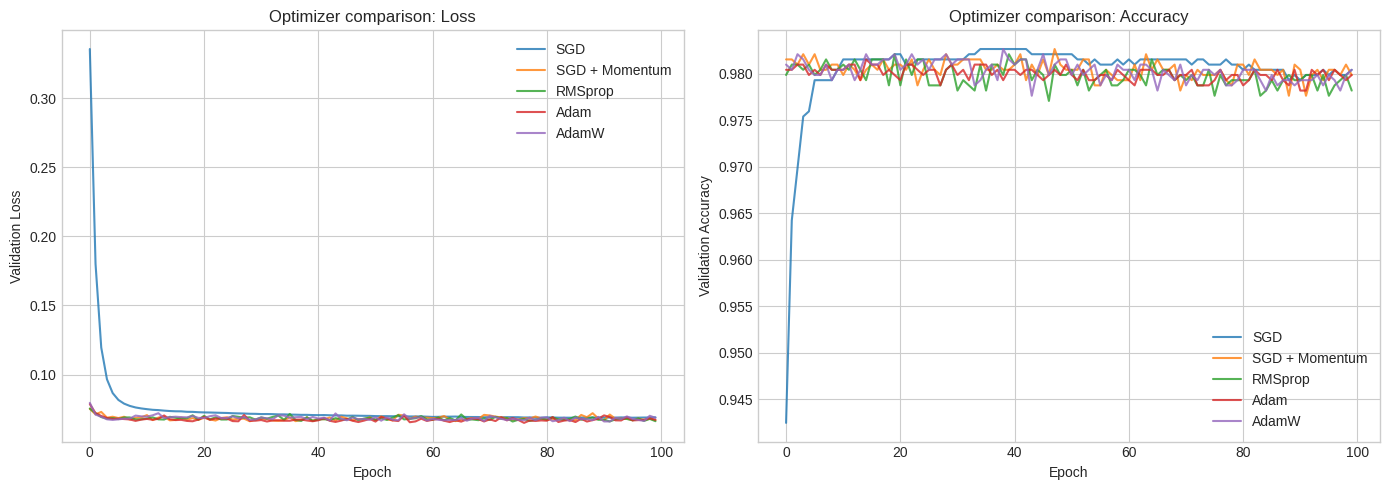

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (train_loss, val_loss, train_acc, val_acc) in optimizer_results.items():
  axes[0].plot(val_loss, label=name, alpha=0.8)
  axes[1].plot(val_acc, label=name, alpha=0.8)

axes[0].set_title('Optimizer comparison: Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].legend()

axes[1].set_title('Optimizer comparison: Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel("Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Test different learning rates
learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_results = {}

for lr in learning_rates:
    print(f"Training with lr={lr}...")
    model = BaselineNet(8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    results = train_model(model, train_loader, val_loader, optimizer, criterion, epochs=100, verbose=False)
    lr_results[lr] = results
    print(f"  Final Val Acc: {results[3][-1]:.2%}")

Training with lr=0.1...
  Final Val Acc: 97.99%
Training with lr=0.01...
  Final Val Acc: 98.10%
Training with lr=0.001...
  Final Val Acc: 98.10%
Training with lr=0.0001...
  Final Val Acc: 98.10%


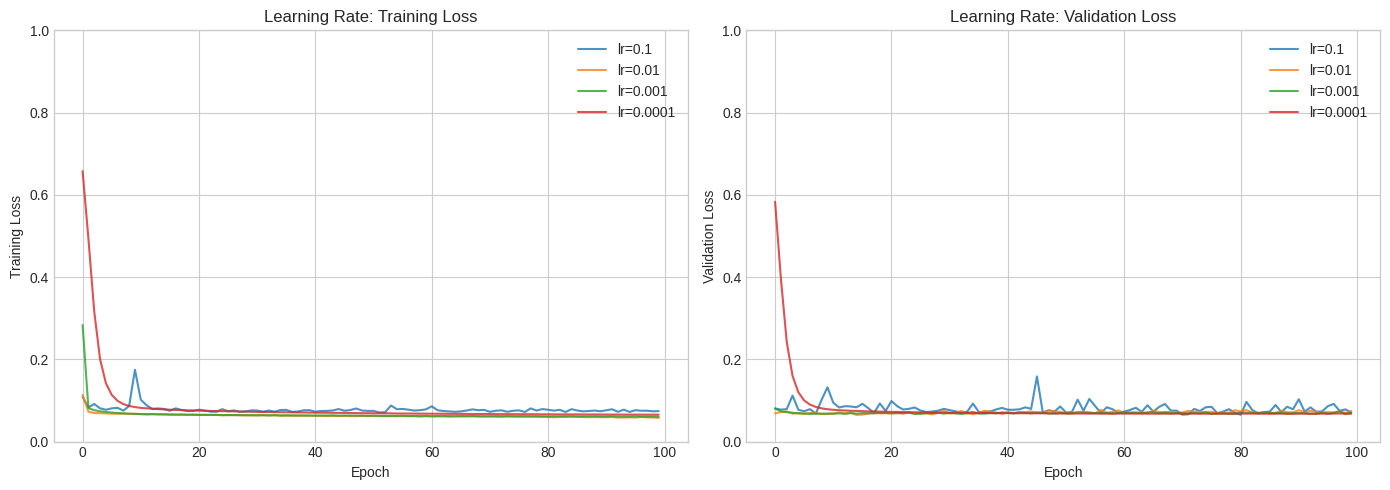

In [ ]:
# Plot LR comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, (train_loss, val_loss, train_acc, val_acc) in lr_results.items():
    axes[0].plot(train_loss, label=f'lr={lr}', alpha=0.8)
    axes[1].plot(val_loss, label=f'lr={lr}', alpha=0.8)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Learning Rate: Training Loss')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Learning Rate: Validation Loss')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

Learning rate scheduling

In [ ]:
# Training with scheduler
def train_with_scheduler(model, train_loader, val_loader, optimizer, scheduler, criterion, epochs=100):
    train_losses, val_losses = [], []
    lrs = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))
        lrs.append(optimizer.param_groups[0]['lr'])

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item()
        val_losses.append(val_loss / len(val_loader))

        # Step scheduler
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_losses[-1])
        else:
            scheduler.step()

    return train_losses, val_losses, lrs

In [ ]:
# Compare schedulers
scheduler_results = {}

# StepLR: Reduce by factor every N epochs
print("StepLR...")
model = BaselineNet(8).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
scheduler_results['StepLR'] = train_with_scheduler(model, train_loader, val_loader, optimizer, scheduler, criterion)

# ExponentialLR: Decay every epoch
print("ExponentialLR...")
model = BaselineNet(8).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
scheduler_results['ExponentialLR'] = train_with_scheduler(model, train_loader, val_loader, optimizer, scheduler, criterion)

# CosineAnnealingLR: Smooth cosine decay
print("CosineAnnealingLR...")
model = BaselineNet(8).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
scheduler_results['CosineAnnealing'] = train_with_scheduler(model, train_loader, val_loader, optimizer, scheduler, criterion)

# ReduceLROnPlateau: Reduce when stuck
print("ReduceLROnPlateau...")
model = BaselineNet(8).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
scheduler_results['ReduceOnPlateau'] = train_with_scheduler(model, train_loader, val_loader, optimizer, scheduler, criterion)

print("Done!")

StepLR...
ExponentialLR...
CosineAnnealingLR...
ReduceLROnPlateau...
Done!


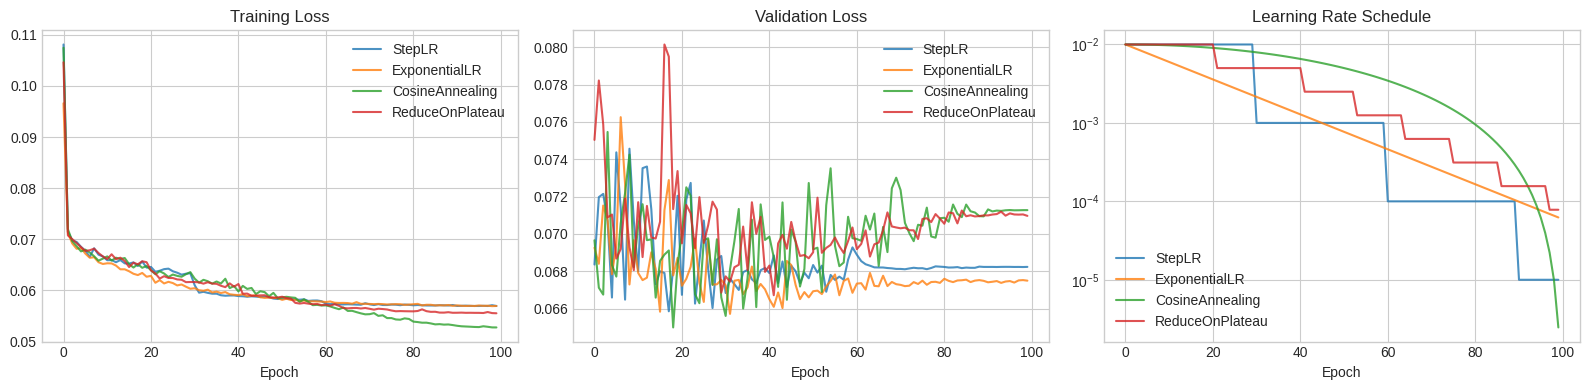

In [ ]:
# Plot scheduler comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, (train_loss, val_loss, lrs) in scheduler_results.items():
    axes[0].plot(train_loss, label=name, alpha=0.8)
    axes[1].plot(val_loss, label=name, alpha=0.8)
    axes[2].plot(lrs, label=name, alpha=0.8)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].legend()

plt.tight_layout()
plt.show()

Dropout

In [ ]:
class DropoutNet(nn.Module):
  def __init__(self, input_size, dropout_rate=0.3):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )
  def forward(self, x):
    return self.net(x)

print(DropoutNet(8))

DropoutNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [ ]:
dropout_rates = [0.0, 0.2, 0.3, 0.5]
dropout_results = {}

for dr in dropout_rates:
  print(f'Training with dropout={dr}. . . ')
  model = DropoutNet(8, dropout_rate=dr).to(device)
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  results = train_model(model, train_loader, val_loader, optimizer, criterion, epochs=100, verbose=False)
  dropout_results[dr] = results
  print(f' Train Acc: {results[2][-1]} | Val Acc: {results[3][-1]:.2%}')


Training with dropout=0.0. . . 
 Train Acc: 0.98253946081855 | Val Acc: 97.82%
Training with dropout=0.2. . . 
 Train Acc: 0.9820505657214694 | Val Acc: 98.04%
Training with dropout=0.3. . . 
 Train Acc: 0.981491828467663 | Val Acc: 97.93%
Training with dropout=0.5. . . 
 Train Acc: 0.9800251431764213 | Val Acc: 97.99%


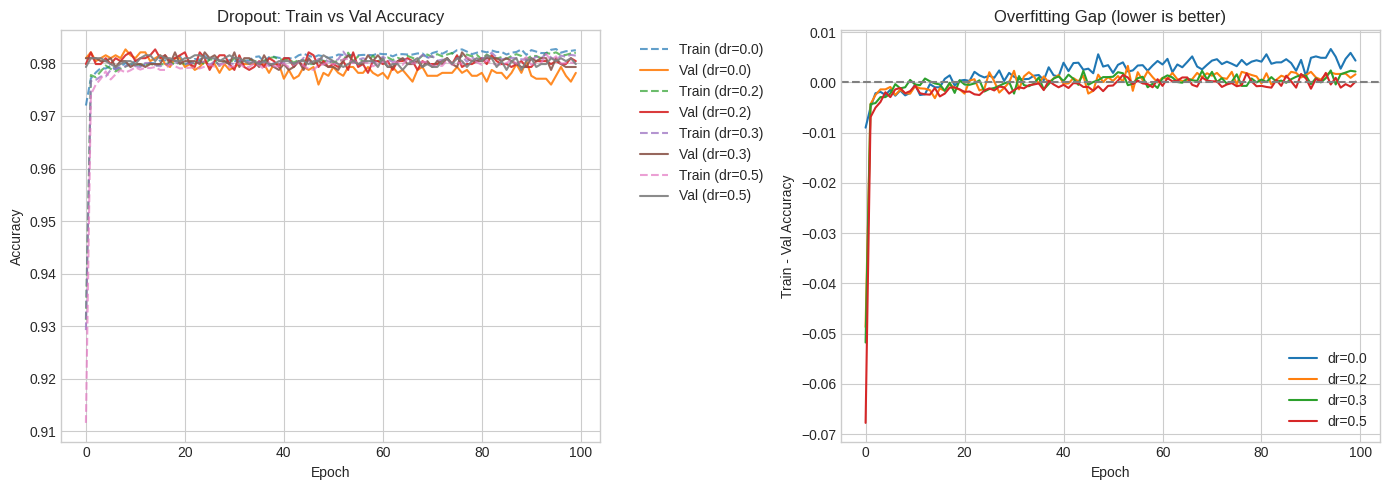

In [ ]:
# Plot dropout comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for dr, (train_loss, val_loss, train_acc, val_acc) in dropout_results.items():
    axes[0].plot(train_acc, label=f'Train (dr={dr})', linestyle='--', alpha=0.7)
    axes[0].plot(val_acc, label=f'Val (dr={dr})', alpha=0.9)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Dropout: Train vs Val Accuracy')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Gap between train and val (overfitting indicator)
for dr, (train_loss, val_loss, train_acc, val_acc) in dropout_results.items():
    gap = [t - v for t, v in zip(train_acc, val_acc)]
    axes[1].plot(gap, label=f'dr={dr}')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train - Val Accuracy')
axes[1].set_title('Overfitting Gap (lower is better)')
axes[1].legend()
axes[1].axhline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
# Model with BatchNorm
class BatchNormNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

print(BatchNormNet(8))

BatchNormNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [ ]:
# Compare: Baseline vs BatchNorm vs Dropout vs Both
class FullRegularizedNet(nn.Module):
    def __init__(self, input_size, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Train all variants
variants = {
    'Baseline': BaselineNet(8),
    'Dropout': DropoutNet(8, 0.3),
    'BatchNorm': BatchNormNet(8),
    'BatchNorm + Dropout': FullRegularizedNet(8, 0.3)
}

variant_results = {}
for name, model in variants.items():
    print(f"Training {name}...")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    results = train_model(model, train_loader, val_loader, optimizer, criterion, epochs=100, verbose=False)
    variant_results[name] = results
    print(f"  Val Acc: {results[3][-1]:.2%}")

Training Baseline...
  Val Acc: 97.82%
Training Dropout...
  Val Acc: 97.88%
Training BatchNorm...
  Val Acc: 97.77%
Training BatchNorm + Dropout...
  Val Acc: 98.04%


In [ ]:
# Evaluate best model on test set
model_es = variants['BatchNorm + Dropout']
model_es.eval()
with torch.no_grad():
    y_pred_prob = model_es(x_test_t)
    y_pred = (y_pred_prob > 0.5).float()

test_acc = (y_pred == y_test_t).float().mean().item()
test_f1 = f1_score(y_test, y_pred.cpu().numpy())

print(f"Test Accuracy: {test_acc:.2%}")
print(f"Test F1 Score: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred.cpu().numpy(), target_names=['Not Pulsar', 'Pulsar']))

Test Accuracy: 98.16%
Test F1 Score: 0.8925

Classification Report:
              precision    recall  f1-score   support

  Not Pulsar       0.98      1.00      0.99      1626
      Pulsar       0.96      0.84      0.89       164

    accuracy                           0.98      1790
   macro avg       0.97      0.92      0.94      1790
weighted avg       0.98      0.98      0.98      1790



---
## Summary

| Technique | Purpose | Typical Values |
|-----------|---------|----------------|
| Adam | Default optimizer | lr=0.001 |
| ReduceLROnPlateau | Adaptive LR | patience=10 |
| Dropout | Prevent overfitting | p=0.2-0.5 |
| BatchNorm | Stabilize training | After linear |
| Weight Decay | L2 regularization | 0.01 |
| Early Stopping | Stop before overfit | patience=15 |
